# Cài đặt và import các thư viện cần thiết

In [1]:
!pip install -qq requests sentence_transformers

In [2]:
import json
import requests
import re
import torch
import numpy as np
from pprint import pprint
from pyvi import ViTokenizer
from tqdm.notebook import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
# Kiểm tra GPU có khả dụng không
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    raise RuntimeError("No GPU found")

print(f'Using device: {device}')

Using device: cuda


In [4]:
DATABASE_NAME = "mydatabase"

# Kết nối database

In [6]:
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="",
  database=DATABASE_NAME
)

print(mydb)

In [7]:
cursor = mydb.cursor()

query = "SELECT * FROM articles"
cursor.execute(query)

rows = cursor.fetchall()

data = []
for row in rows:
    id = row[0]
    publish_time = row[1]
    author = row[2]
    title = row[3]
    snippet = row[4]
    content = row[5]
    category = row[6]
    data.append({'id': id, 'title': title, 'content': content, 'cat': category, 'publish_time': publish_time, 'author': author, 'snippet': snippet})

In [8]:
query = "SELECT * FROM processed_texts"
cursor.execute(query)

rows = cursor.fetchall()

processed_data = []
for row in rows:
    id = row[0]
    content = row[1]
    category = row[2]
    processed_data.append({'id': id, 'content': content, 'cat': category})

# Tải vocab

In [9]:
vocab = set()

with open('vocabulary.tex', 'r', encoding='utf-8') as fin:
    for line in fin:
        a = line.split()
        if len(a) == 1:
            word = " "
        else:
            word = a[1]
        vocab.add(word)
    
len(vocab)

189

# Nhóm các bài báo theo từng thể loại

In [10]:
grouped_data = defaultdict(list)

for doc in processed_data:
    cat = doc['cat']
    grouped_data[cat].append({'id': doc['id'], 'content': doc['content']})

# Trích chọn đặc trưng, tạo vector biểu diễn cho dữ liệu

## Dùng TF-IDF

In [11]:
def embeddings_with_tfidf(data):
    data_embeddings = np.zeros((len(data), len(vocab)))
    data_id = []
    
    query = "select * from tfidf where doc_id=%s"

    for i, article in enumerate(data):
        doc_id = article['id']
        data_id.append(doc_id)
        cursor.execute(query, (doc_id,))
        tfidf_values = cursor.fetchall()
        for row in tfidf_values:
            j = int(row[1])
            data_embeddings[i][j] = row[-1]
            
    return data_embeddings, data_id

## Dùng SBert

In [12]:
from sentence_transformers import SentenceTransformer

# Chọn mô hình và chuyển sang GPU
model_sbert = SentenceTransformer('keepitreal/vietnamese-sbert', device=device)

c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [13]:
def embeddings_with_sbert(data):
    data_embeddings = []
    data_id = []

    for article in tqdm(data, desc=f"Encoding articles ", unit='article'):
        doc_id = article['id']
        data_id.append(doc_id)
        embedding = model_sbert.encode(article['content'])
        data_embeddings.append(embedding)
        
    return data_embeddings, data_id

# Hàm đánh giá chất lượng phân cụm

In [15]:
import warnings
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Tắt tất cả các cảnh báo FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

def evaluate_clustering(embeddings, labels, model=None):
    sil_score = silhouette_score(embeddings, labels)
    db_score = davies_bouldin_score(embeddings, labels)
    ch_score = calinski_harabasz_score(embeddings, labels)

    # Tính WCSS nếu có model KMeans
    wcss = None
    if model and hasattr(model, 'inertia_'):
        wcss = model.inertia_

    return sil_score, db_score, ch_score, wcss

In [14]:
cat_mapping = {
    "Xã hội": "xa_hoi",
    "Kinh tế": "kinh_te",
    "Du lịch": "du_lich",
    "Giáo dục": "giao_duc",
    "Giải trí": "giai_tri",
    "Văn hóa": "van_hoa",
    "KHCN": "khcn",
    "Sức khỏe": "suc_khoe",
    "Pháp luật": "phap_luat",
    "Thể thao": "the_thao",
    "Thế giới": "the_gioi",
    "Chính trị": "chinh_tri"
}

# So sánh độ tương của kết quả phân cụm giữa Kmeans và HAC

In [37]:
from sklearn.metrics import adjusted_rand_score
import seaborn as sns
import pandas as pd

In [21]:
cat_mapping.keys()

dict_keys(['Xã hội', 'Kinh tế', 'Du lịch', 'Giáo dục', 'Giải trí', 'Văn hóa', 'KHCN', 'Sức khỏe', 'Pháp luật', 'Thể thao', 'Thế giới', 'Chính trị'])

In [26]:
algo = ['kmeans', 'hac']
vector = ['tfidf', 'sbert']
ari_results = {}
for cat in cat_mapping.keys():
    for i in vector:
        table_name = f"clustering_{cat_mapping[cat]}_using_kmeans_with_{i}"
        query = f"select * from {table_name}"
        cursor.execute(query)
        labels = cursor.fetchall()
        labels_kmeans = {}
        labels_hac = {}
        for label in labels:
            doc_id = label[0]
            labels_kmeans[doc_id] = label[1]
            
        table_name = f"clustering_{cat_mapping[cat]}_using_hac_with_{i}"
        query = f"select * from {table_name}"
        cursor.execute(query)
        labels = cursor.fetchall()
        for label in labels:
            doc_id = label[0]
            labels_hac[doc_id] = label[1]
            
        y_kmeans = []
        y_hac = []
        for doc_id in labels_kmeans.keys():
            y_kmeans.append(labels_kmeans[doc_id])
            y_hac.append(labels_hac[doc_id])
            
        ari_results[f'{cat_mapping[cat]}_{i}'] = adjusted_rand_score(y_kmeans, y_hac)
            
        

# data_embeddings, data_id = embeddings_with_sbert(grouped_data[cat])

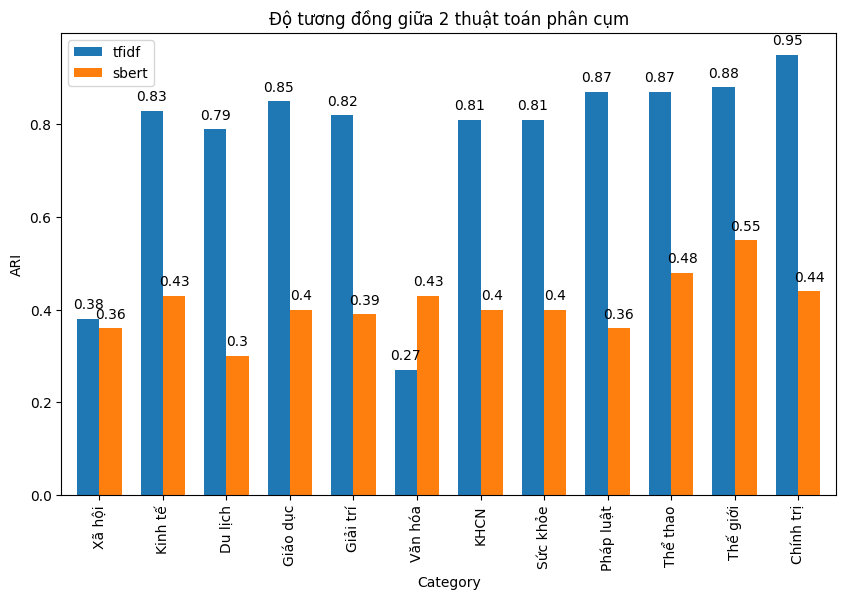

In [50]:
# Vẽ biểu đồ cột
t = []
for cat in cat_mapping.keys():
    ari1 = round(ari_results[f'{cat_mapping[cat]}_tfidf'], 2)
    ari2 =  round(ari_results[f'{cat_mapping[cat]}_sbert'], 2)
    r = [cat, ari1, ari2]
    t.append(r)
    
df = pd.DataFrame(t, columns=['Category', 'tfidf', 'sbert'])
ax = df.plot(x='Category', 
        kind='bar',
        stacked=False, 
        title='Độ tương đồng giữa 2 thuật toán phân cụm',
        figsize=(10, 6),
        width=0.7) 

plt.ylabel('ARI')
# Thêm số lượng ở trên mỗi cột
for p in ax.patches:
    ax.annotate(round(p.get_height(), 2), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

In [51]:
metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index']
scores = {}
for m in metrics:
    scores[m] = []
for cat in cat_mapping.keys():
    data_embeddings_with_tfidf, data_id_with_tfidf = embeddings_with_tfidf(grouped_data[cat])
    data_embeddings_with_sbert, data_id_with_sbert = embeddings_with_sbert(grouped_data[cat])
    r = {}
    for m in metrics:
        r[m] = [cat]
    
    for i in algo:
        table_name = f"clustering_{cat_mapping[cat]}_using_{i}_with_tfidf"
        query = f"select * from {table_name}"
        cursor.execute(query)
        rows = cursor.fetchall()
        labels_mapping = {}
        for row in rows:
            doc_id = row[0]
            labels_mapping[doc_id] = row[1]
            
        labels = []
        for id in data_id_with_tfidf:
            labels.append(labels_mapping[id])
        
        results = evaluate_clustering(data_embeddings_with_tfidf, labels)
        for idx, m in enumerate(metrics):
            r[m].append(results[idx])
        
        table_name = f"clustering_{cat_mapping[cat]}_using_{i}_with_sbert"
        query = f"select * from {table_name}"
        cursor.execute(query)
        rows = cursor.fetchall()
        labels_mapping = {}
        for row in rows:
            doc_id = row[0]
            labels_mapping[doc_id] = row[1]
            
        labels = []
        for id in data_id_with_sbert:
            labels.append(labels_mapping[id])
        
        results = evaluate_clustering(data_embeddings_with_sbert, labels)
        for idx, m in enumerate(metrics):
            r[m].append(results[idx])
            
    for m in metrics:
        scores[m].append(r[m])

Encoding articles :   0%|          | 0/3075 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/3352 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1289 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1399 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1245 [00:00<?, ?article/s]

...

Encoding articles :   0%|          | 0/1407 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1461 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1326 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/1449 [00:00<?, ?article/s]

Encoding articles :   0%|          | 0/961 [00:00<?, ?article/s]

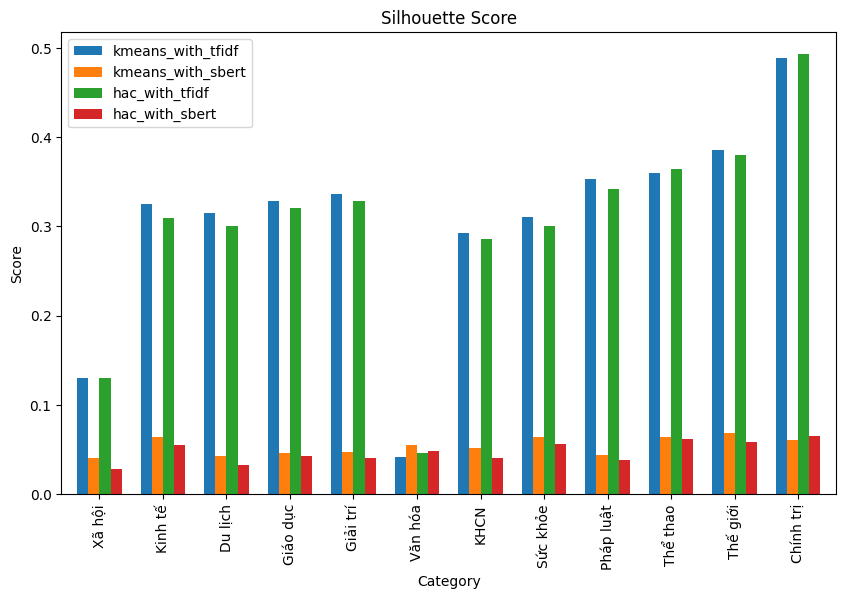

In [53]:
df = pd.DataFrame(scores[metrics[0]], columns=['Category', 'kmeans_with_tfidf', 'kmeans_with_sbert', 'hac_with_tfidf', 'hac_with_sbert'])
ax = df.plot(x='Category', 
        kind='bar',
        stacked=False, 
        title=metrics[0],
        figsize=(10, 6),
        width=0.7) 

plt.ylabel('Score')
plt.show()

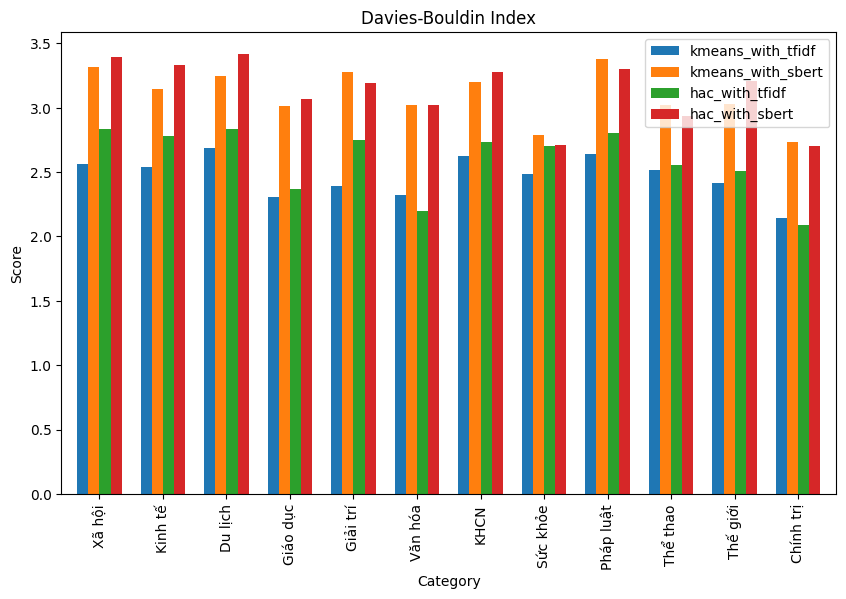

In [55]:
df = pd.DataFrame(scores[metrics[1]], columns=['Category', 'kmeans_with_tfidf', 'kmeans_with_sbert', 'hac_with_tfidf', 'hac_with_sbert'])
ax = df.plot(x='Category', 
        kind='bar',
        stacked=False, 
        title=metrics[1],
        figsize=(10, 6),
        width=0.7) 

plt.ylabel('Score')
plt.show()

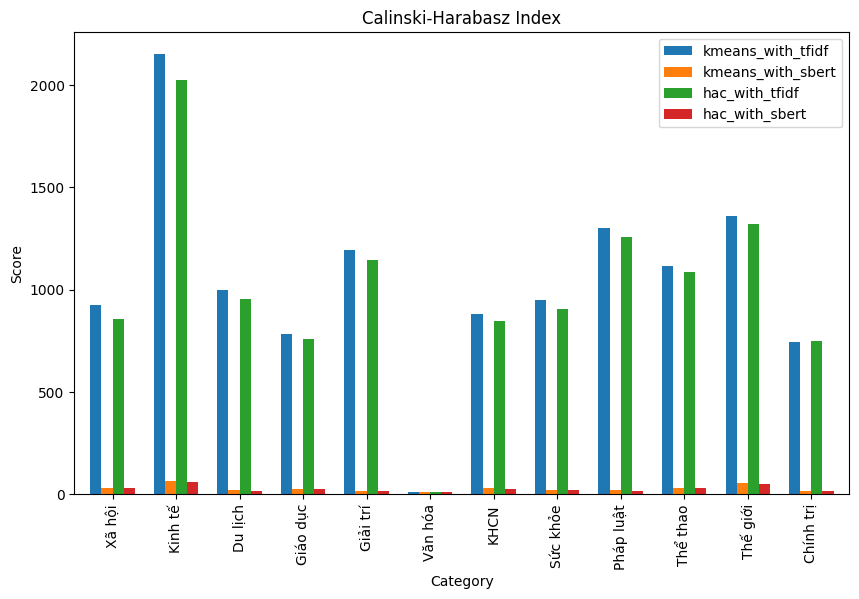

In [56]:
df = pd.DataFrame(scores[metrics[2]], columns=['Category', 'kmeans_with_tfidf', 'kmeans_with_sbert', 'hac_with_tfidf', 'hac_with_sbert'])
ax = df.plot(x='Category', 
        kind='bar',
        stacked=False, 
        title=metrics[2],
        figsize=(10, 6),
        width=0.7) 

plt.ylabel('Score')
plt.show()